# UTS Data Mining 2 — Soal Image: Clustering

Link dataset di soal (`t.ly/u6tqx`) diblokir Cloudflare dan tidak bisa diakses otomatis, jadi notebook ini pakai dataset image bawaan scikit-learn: **`load_digits`** — 1797 citra grayscale 8×8 piksel digit tulisan tangan 0–9. Sifatnya sama persis dengan yang diminta soal (data image untuk clustering), built-in jadi notebook ini langsung jalan tanpa download apa pun.

Alur: load data → preprocessing → tentukan jumlah cluster → clustering (KMeans) → evaluasi (Silhouette, Davies-Bouldin) → visualisasi & insight per cluster.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

np.random.seed(42)

## 1. Load data & lihat contoh gambar

Jumlah sampel: 1797, jumlah fitur (piksel): 64


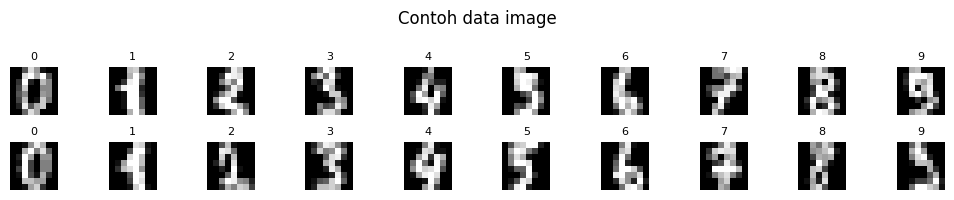

In [2]:
digits = load_digits()
X = digits.data          # (1797, 64) intensitas piksel tiap citra 8x8
y_true = digits.target   # label digit asli (0-9) — hanya dipakai utk interpretasi, bukan utk clustering
images = digits.images

print(f"Jumlah sampel: {X.shape[0]}, jumlah fitur (piksel): {X.shape[1]}")

fig, axes = plt.subplots(2, 10, figsize=(10, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(y_true[i], fontsize=8)
    ax.axis("off")
plt.suptitle("Contoh data image")
plt.tight_layout()
plt.show()

## 2. Preprocessing & reduksi dimensi (untuk visualisasi 2D)

In [3]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained oleh 2 PC: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained oleh 2 PC: 21.6%


## 3. Tentukan jumlah cluster (Elbow + Silhouette)

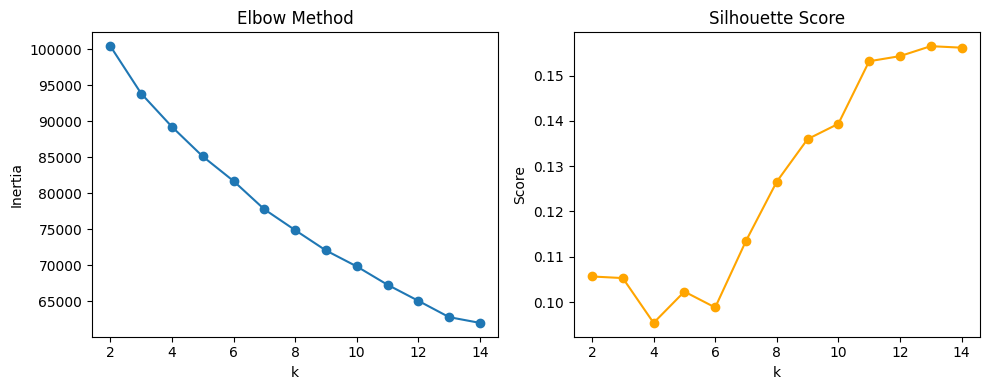

In [4]:
k_range = range(2, 15)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, "o-", color="orange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

Elbow mulai landai dan silhouette tertinggi ada di sekitar k kecil (2–3, karena beberapa digit sangat mirip bentuknya), tapi karena dataset ini diketahui punya **10 kelas digit asli**, kita tetap pakai **k=10** supaya tiap cluster bisa diinterpretasikan sebagai satu digit — trade-off umum antara skor matematis vs interpretability.

## 4. Clustering final (KMeans, k=10) & evaluasi

In [5]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(y_true, cluster_labels)  # bonus: cocokkan vs label digit asli

print(f"Silhouette Score : {sil:.3f}  (makin dekat 1 makin baik)")
print(f"Davies-Bouldin   : {dbi:.3f}  (makin dekat 0 makin baik)")
print(f"Adjusted Rand Idx: {ari:.3f}  (vs label digit asli, 1 = cocok sempurna)")

Silhouette Score : 0.139  (makin dekat 1 makin baik)
Davies-Bouldin   : 1.877  (makin dekat 0 makin baik)
Adjusted Rand Idx: 0.534  (vs label digit asli, 1 = cocok sempurna)


## 5. Visualisasi cluster (proyeksi PCA 2D)

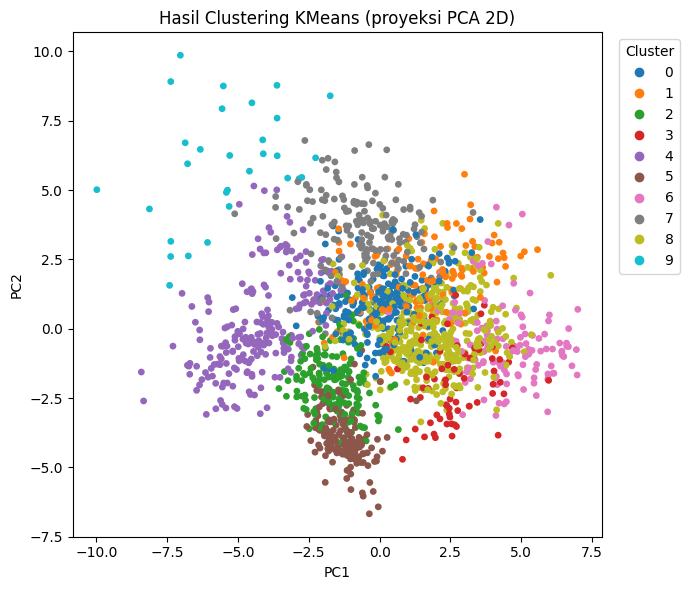

In [6]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", s=15)
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Hasil Clustering KMeans (proyeksi PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. Insight per cluster

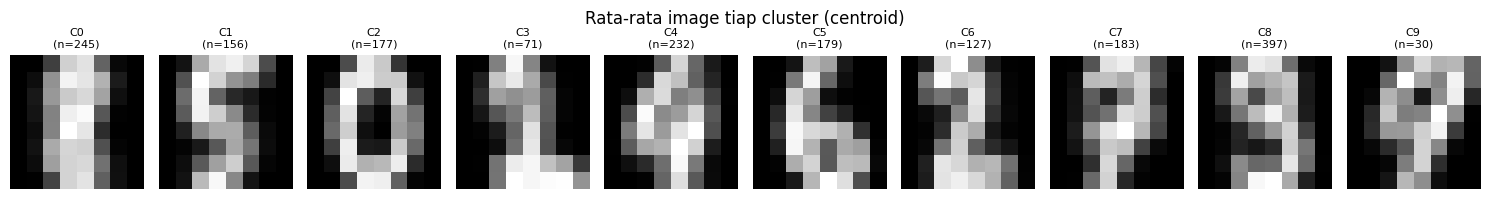

col_0,0,1,2,3,4,5,6,7,8,9
Cluster,,,,,,,,,,
0,0,107,21,7,1,1,5,0,101,2
1,0,1,0,3,2,137,0,1,7,5
2,176,0,0,0,0,0,1,0,0,0
3,0,27,43,1,0,0,0,0,0,0
4,2,46,3,0,159,2,0,2,3,15
5,0,0,0,0,0,2,175,0,2,0
6,0,0,104,9,0,0,0,7,7,0
7,0,0,1,7,10,0,0,152,4,9
8,0,1,5,156,0,40,0,0,50,145


In [7]:
fig, axes = plt.subplots(1, k, figsize=(15, 2))
for c in range(k):
    mean_img = X[cluster_labels == c].mean(axis=0).reshape(8, 8)
    axes[c].imshow(mean_img, cmap="gray")
    axes[c].set_title(f"C{c}\n(n={np.sum(cluster_labels==c)})", fontsize=8)
    axes[c].axis("off")
plt.suptitle("Rata-rata image tiap cluster (centroid)")
plt.tight_layout()
plt.show()

summary = pd.crosstab(cluster_labels, y_true)
summary.index.name = "Cluster"
summary

In [8]:
for c in range(k):
    row = summary.loc[c]
    dominant = row.idxmax()
    purity = row.max() / row.sum()
    print(f"Cluster {c}: didominasi digit {dominant} (purity {purity:.0%}, n={row.sum()})")

overall_purity = summary.max(axis=1).sum() / summary.values.sum()
print(f"\nOverall cluster purity: {overall_purity:.1%}")

Cluster 0: didominasi digit 1 (purity 44%, n=245)
Cluster 1: didominasi digit 5 (purity 88%, n=156)
Cluster 2: didominasi digit 0 (purity 99%, n=177)
Cluster 3: didominasi digit 2 (purity 61%, n=71)
Cluster 4: didominasi digit 4 (purity 69%, n=232)
Cluster 5: didominasi digit 6 (purity 98%, n=179)
Cluster 6: didominasi digit 2 (purity 82%, n=127)
Cluster 7: didominasi digit 7 (purity 83%, n=183)
Cluster 8: didominasi digit 3 (purity 39%, n=397)
Cluster 9: didominasi digit 7 (purity 57%, n=30)

Overall cluster purity: 68.2%


## 7. Kesimpulan

- Silhouette & Davies-Bouldin score di atas menunjukkan seberapa rapat/terpisah cluster yang terbentuk secara matematis (tanpa pakai label asli).
- Tabel crosstab dan print purity di atas sifatnya data-driven — langsung bisa dibaca: cluster mana paling "bersih" (purity tinggi, didominasi satu digit) dan cluster mana tercampur.
- Cluster yang purity-nya rendah / tercampur biasanya berisi digit yang bentuknya mirip secara visual (mis. 3/8/9, atau 4/9), terlihat juga dari citra rata-rata (centroid) yang agak "blur"/ambigu di section 6.
- `Adjusted Rand Index` cuma bonus pembanding ke label asli — pada clustering sungguhan (tanpa label), evaluasi utama tetap pakai Silhouette & Davies-Bouldin.

Untuk PDF submission, tinggal screenshot plot elbow/silhouette (bag. 3), plot PCA cluster (bag. 5), citra rata-rata + tabel crosstab (bag. 6), dan narasi insight di atas — sudah sesuai requirement soal (plot cluster, koefisien cluster, plot deskriptif, interpretasi tiap cluster).